# Uporedna analiza svih modela


---

Ovaj notebook predstavlja završnu, sintetičku analizu projekta odnosno poređenje sva četiri implementirana modela na **identičnom test skupu** (jun 2025 – jun 2026).

Centralna ideja projekta bila je da se isti zadatak, predikcija PM2.5 koncentracije 24 sata unapred reši pomoću četiri različita algoritma, a zatim da se rezultati objektivno uporede. Fer poređenje zahteva da svi modeli:
- budu trenirani na istim podacima (isti train skup)
- budu evaluirani na istim podacima (isti test skup)
- imaju pristup istom skupu feature-a

Svi ti uslovi su ispunjeni u ovom projektu.

**Modeli koji se porede:**
| Model | Pristup |
|-------|---------|
| XGBoost | Gradijentni busting, level-wise rast stabala |
| LightGBM | Gradijentni busting, leaf-wise rast stabala |
| KNN | Analogija K najsličnijih istorijskih primera |
| LSTM | Rekurentna neuronska mreža sa memorijskim kapijama |

## 1. Uvoz biblioteka i učitavanje svih modela

Učitavamo sva četiri istrenirana modela sa diska. Svaki model je sačuvan u odgovarajućem formatu: gradient boosting modeli kao `.pkl`, LSTM kao `.keras`, a KNN zajedno sa svojim scalerom jer zahteva normalizaciju feature-a pre traženja suseda.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

from src.data_prep import prepare_city_data
from src.split import time_series_split, get_X_y
from src.evaluate import evaluate_predictions
from src.aqi_utils import pm25_to_aqi_category
from src.models.xgboost_model  import get_xgb_feature_columns,  predict_xgb
from src.models.lightgbm_model import get_lgbm_feature_columns, predict_lgbm
from src.models.knn_model       import get_knn_feature_columns,  predict_knn
from src.models.lstm_model      import build_sequences, scale_sequence_data, SEQUENCE_FEATURES, SEQ_LENGTH
from src.visualize import (
    print_metrics_table, plot_metrics_comparison, plot_timeseries_all_models,
    plot_aqi_distribution, plot_extreme_peaks_analysis,
)

CITY    = 'Beograd'
CSV     = f'../data/raw/{CITY.lower()}.csv'
RESULTS = '../results'

print('Biblioteke učitane.')

Biblioteke učitane.


In [2]:
xgb_model   = joblib.load(f'{RESULTS}/xgboost/xgboost_model_{CITY}.pkl')
lgbm_model  = joblib.load(f'{RESULTS}/lightgbm/lightgbm_model_{CITY}.pkl')
knn_model   = joblib.load(f'{RESULTS}/knn/knn_model_{CITY}.pkl')
knn_scaler  = joblib.load(f'{RESULTS}/knn/knn_scaler_{CITY}.pkl')
lstm_model  = load_model(f'{RESULTS}/lstm/lstm_model_{CITY}.keras')
lstm_scaler = joblib.load(f'{RESULTS}/lstm/lstm_scaler_{CITY}.pkl')

print('Svi modeli uspešno učitani.')

Svi modeli uspešno učitani.


## 2. Priprema podataka

Koristimo isti `prepare_city_data` pipeline i isti `time_series_split` kao pri treniranju što garantuje da test skup koji vidimo ovde bude identičan onom na kome su modeli evaluirani tokom treninga.

Gradient boosting modeli i KNN primaju tabelarni ulaz (jedan red po vremenskom koraku), dok LSTM prima sekvencijalni ulaz (matrica 48 sati × 16 feature-a po primeru). Zbog toga LSTM ima neznatno kraći test skup, prvih 48 sati nema kompletan ulazni prozor.

In [3]:
df = prepare_city_data(CSV, city_name=CITY)
train_df, val_df, test_df = time_series_split(df)

X_test_xgb,  y_test = get_X_y(test_df, get_xgb_feature_columns())
X_test_lgbm, _      = get_X_y(test_df, get_lgbm_feature_columns())
X_test_knn,  _      = get_X_y(test_df, get_knn_feature_columns())

X_train_seq, y_train_seq = build_sequences(train_df)
X_val_seq,   y_val_seq   = build_sequences(val_df)
X_test_seq,  y_test_lstm = build_sequences(test_df)
X_train_seq, X_val_seq, X_test_seq, _ = scale_sequence_data(X_train_seq, X_val_seq, X_test_seq)

print(f'Test skup: {len(y_test):,} sati')
print(f'Test skup (LSTM): {len(y_test_lstm):,} sati (kraći zbog sekvenci od 48h)')

Test skup: 8,856 sati
Test skup (LSTM): 8,808 sati (kraći zbog sekvenci od 48h)


## 3. Predikcije svih modela

Generišemo predikcije sva četiri modela. Svi pozivi su standardizovani kroz odgovarajuće `predict_*` funkcije iz projektnih modula, što omogućava lako proširenje na nove modele u budućnosti.

In [4]:
y_pred_xgb  = np.maximum(predict_xgb(xgb_model, X_test_xgb),   0)
y_pred_lgbm = np.maximum(predict_lgbm(lgbm_model, X_test_lgbm), 0)
y_pred_knn  = np.maximum(predict_knn(knn_model, knn_scaler, X_test_knn), 0)
y_pred_lstm = np.maximum(lstm_model.predict(X_test_seq, verbose=0).flatten(), 0)

print('Predikcije generisane za sve modele.')

Predikcije generisane za sve modele.


## 4. Uporedna tabela metrika

Ovo je centralna tabela projekta koja objektivno poredi sva četiri modela na istom test skupu. Svi modeli su videli iste podatke za trening i evaluiraju se na istom periodu (jun 2025 – jun 2026), što čini poređenje potpuno fer.

Napomena: LSTM se evaluira na svom test skupu (`y_test_lstm`) koji je za 48 sati kraći, dok se ostala tri modela evaluiraju na punom `y_test`.

In [5]:
results = [
    evaluate_predictions(y_test,      y_pred_xgb,  'XGBoost'),
    evaluate_predictions(y_test,      y_pred_lgbm, 'LightGBM'),
    evaluate_predictions(y_test,      y_pred_knn,  'KNN'),
    evaluate_predictions(y_test_lstm, y_pred_lstm, 'LSTM'),
]

results_df = print_metrics_table(results)

print()
print(f'Pobednik po RMSE:  {results_df["RMSE"].idxmin()}')
print(f'Pobednik po MAE:   {results_df["MAE"].idxmin()}')
print(f'Pobednik po R²:    {results_df["R2"].idxmax()}')

=== Rezultati na test skupu ===
             RMSE     MAE      R2
model                            
LSTM      13.1793  8.0589  0.4637
XGBoost   13.2409  7.8948  0.4563
KNN       13.3906  8.1458  0.4439
LightGBM  13.4117  8.0944  0.4422

RMSE — greška u μg/m³, veće greške se kažnjavaju jače (kvadratna kazna)
MAE  — prosečna apsolutna greška u μg/m³
R²   — udeo varijanse PM2.5 koji model objašnjava (1.0 = savršeno)

Pobednik po RMSE:  LSTM
Pobednik po MAE:   XGBoost
Pobednik po R²:    LSTM


## 5. Grafik: poređenje RMSE, MAE, R²

Vizualizujemo sve tri metrike kao stupčaste grafike, sortirane od najboljeg ka najgorem. Strelice u naslovu (↓ i ↑) su podsetnik u kom smeru je bolja vrednost: RMSE i MAE su greške pa su manje vrednosti bolje, dok R² meri preciznost pa su veće vrednosti bolje.

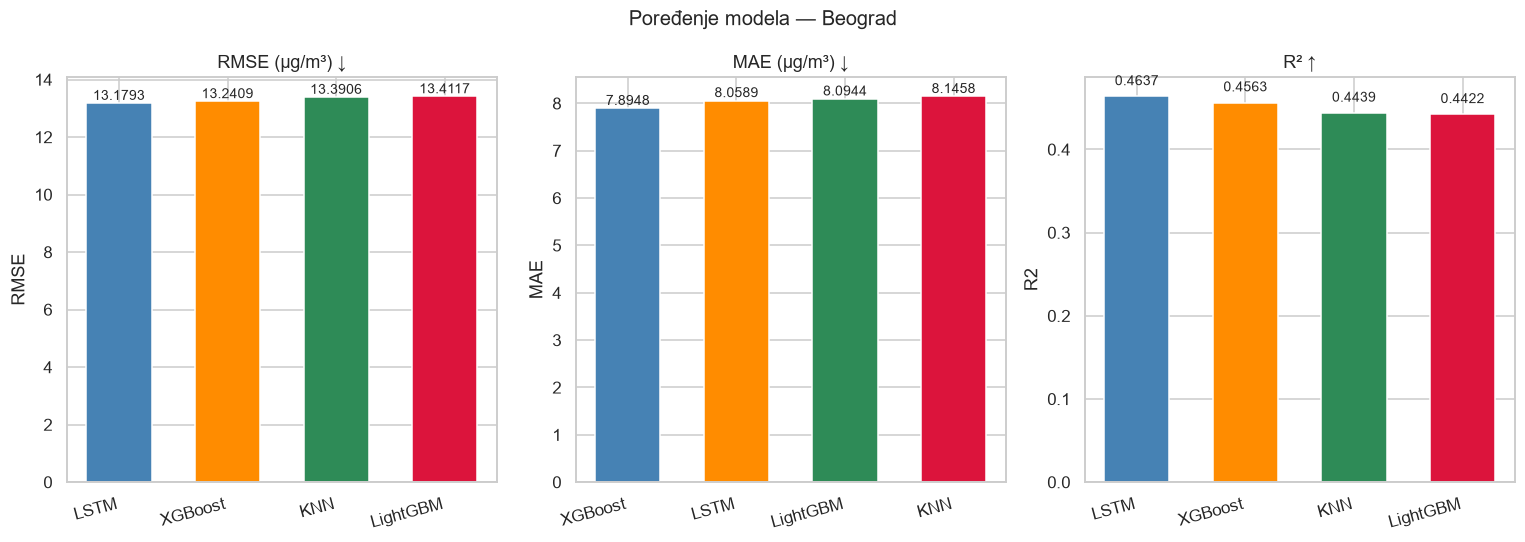

In [6]:
plot_metrics_comparison(results_df, CITY, results_dir=RESULTS)

## 6. Vremenska serija: svi modeli na istom grafiku

Prikazujemo prvih 300 sati test skupa sa svim modelima na istom grafiku. Ovo nam omogućava da vizuelno procenimo da li postoje sistematske razlike između modela npr. da li neki model konzistentno kasni ili potcenjuje pikove.

LSTM počinje 48 sati kasnije od ostalih modela (zbog dužine ulazne sekvence), pa su mu datumi na x-osi pomereni za 2 dana.

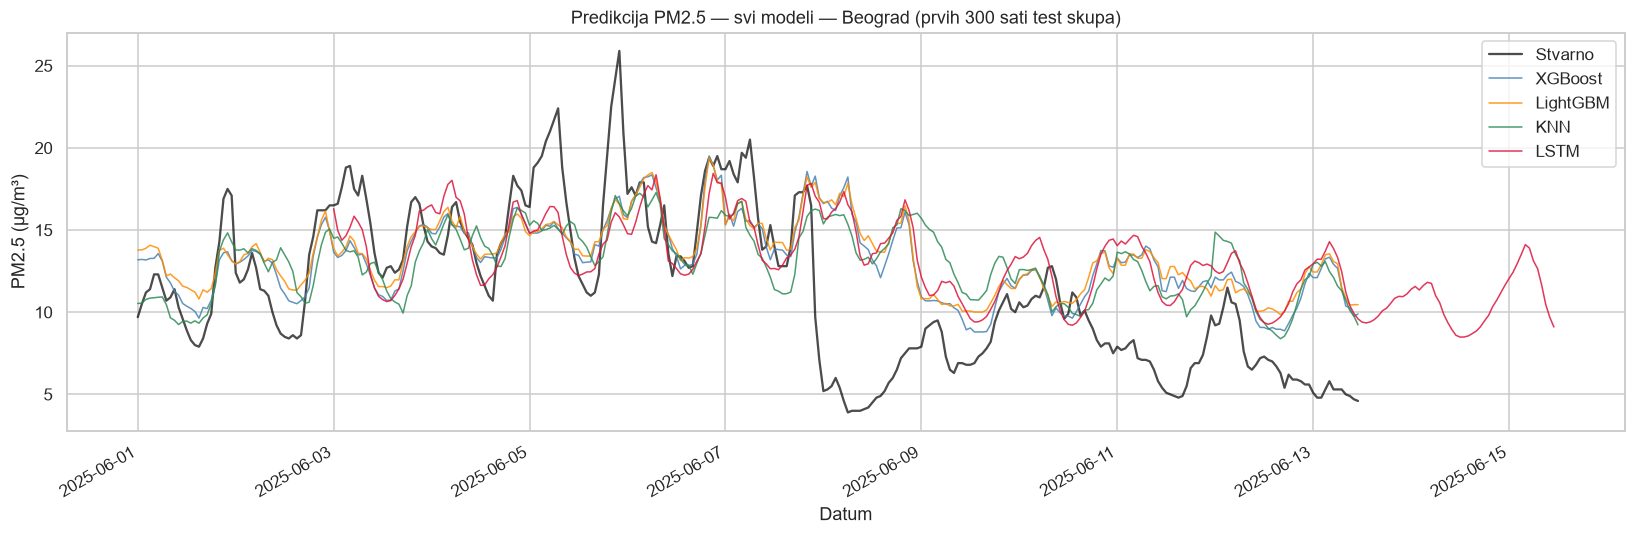

In [7]:
lstm_offset = len(test_df) - len(y_test_lstm)
dates_main = test_df['date'].values
dates_lstm = test_df['date'].values[lstm_offset:]

plot_timeseries_all_models(
    dates_main, y_test, dates_lstm, y_test_lstm,
    predictions={
        'XGBoost':  (y_pred_xgb,  'steelblue'),
        'LightGBM': (y_pred_lgbm, 'darkorange'),
        'KNN':      (y_pred_knn,  'seagreen'),
        'LSTM':     (y_pred_lstm, 'crimson'),
    },
    city=CITY, results_dir=RESULTS, n_hours=300,
)

## 7. AQI kategorije: poređenje raspodele

Konačni test praktične upotrebljivosti modela: da li svaki model ispravno procenjuje **opasnost po zdravlje**? Grafik poredi koliko sati u test skupu svaki model svrstava u svaku AQI kategoriju, naspram stvarnih vrednosti.

Za sistem ranog upozoravanja posebno je kritično da model ne **potcenjuje** kategorije "Zagađen" i "Veoma zagađen"; lažno negativna predikcija (proglasiti opasan dan bezbednim) je daleko opasnija od lažno pozitivne.

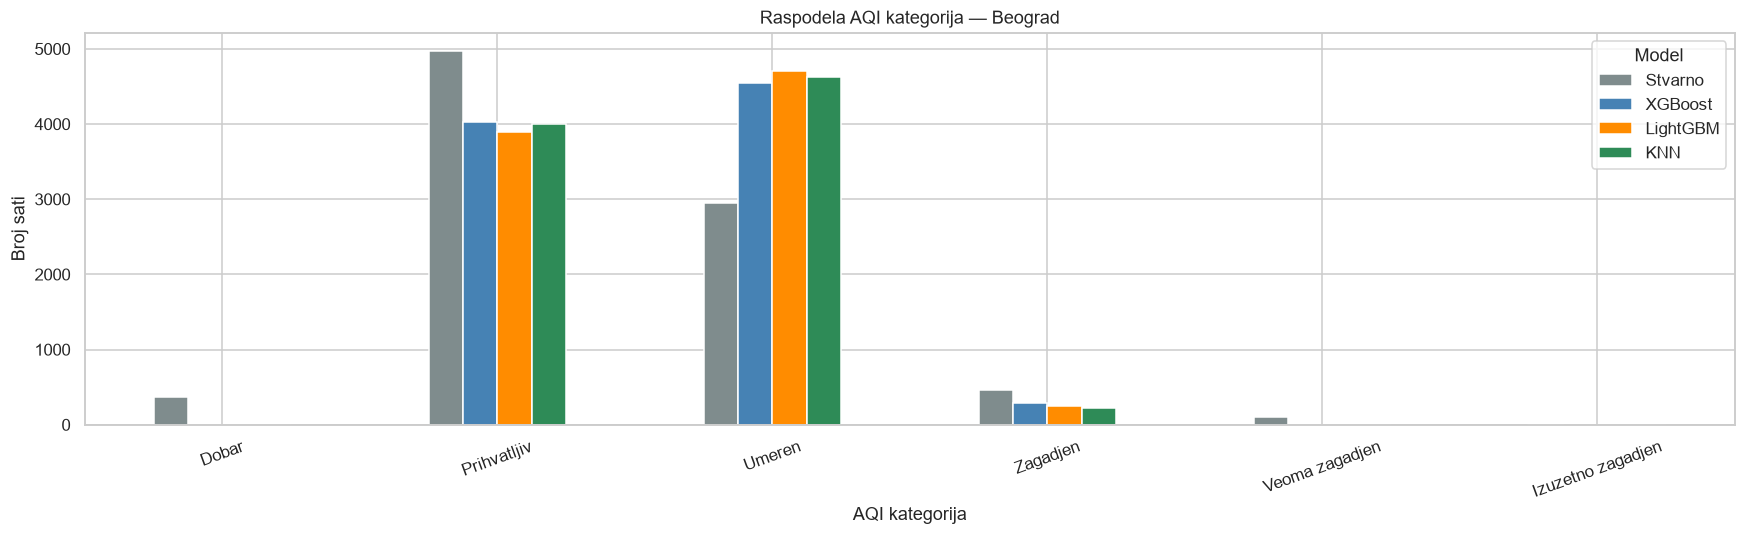


LSTM AQI raspodela (posebno, kraci test opseg):
Umeren         4808
Prihvatljiv    3791
Zagadjen        209


In [8]:
plot_aqi_distribution(
    y_test,
    {'XGBoost': y_pred_xgb, 'LightGBM': y_pred_lgbm, 'KNN': y_pred_knn},
    city=CITY, filename=f'aqi_all_models_{CITY}.png', results_dir=RESULTS,
)

print('\nLSTM AQI raspodela (posebno, kraci test opseg):')
print(pd.Series(y_pred_lstm).apply(pm25_to_aqi_category).value_counts().to_string())

## 8. Analiza ekstremnih pikova zagađenja

Specifikacija projekta postavlja konkretno pitanje: **"koji algoritam
najpreciznije predviđa ekstremne pikove zagađenja?"** Dosadašnje metrike
(RMSE/MAE/R²) su računate na **celom** test skupu, gde većinu čine sati
sa umerenim zagađenjem što razblažuje razliku između modela baš u
trenucima kada je preciznost najkritičnija (opasne koncentracije).

Ovde računamo iste metrike, ali **isključivo** na satima gde je stvarna
PM2.5 vrednost prešla SEPA prag za "Veoma zagađen" (90 μg/m³). Model sa
najmanjim RMSE-om SAMO na ovim tačkama je taj koji najbolje hvata
ekstremne epizode, bez obzira na to kako se ponaša "prosečnog" dana.

Broj sati sa PM2.5 > 90.0 μg/m³ ("Veoma zagađen" i gore) u test skupu: 114
To je 1.29% test skupa.

=== Metrike SAMO na ekstremnim pikovima (PM2.5 > 90.0) ===
             RMSE      MAE       R2
model                              
XGBoost   68.4431  65.5269 -14.3204
LightGBM  68.5205  65.2457 -14.3551
KNN       69.8905  67.6821 -14.9753


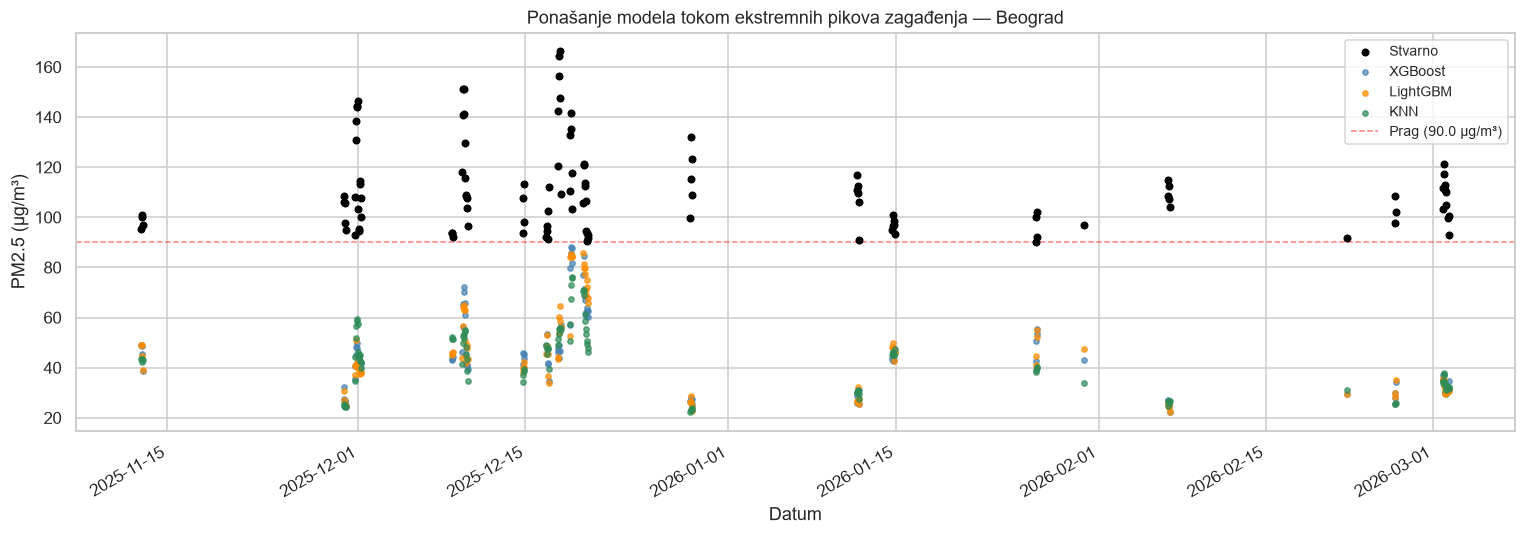

In [9]:
peak_results = plot_extreme_peaks_analysis(
    dates_main, y_test,
    predictions={
        'XGBoost':  (y_pred_xgb,  'steelblue'),
        'LightGBM': (y_pred_lgbm, 'darkorange'),
        'KNN':      (y_pred_knn,  'seagreen'),
    },
    city=CITY, results_dir=RESULTS, threshold=90.0,
)

LSTM ima drugačiju dužinu test niza (zbog 48h ulazne sekvence), pa se
njegova ekstremna analiza računa zasebno na `y_test_lstm`, sa istim pragom.

In [10]:
lstm_peak_mask = np.array(y_test_lstm) > 90.0
n_lstm_peaks = lstm_peak_mask.sum()

print(f'LSTM test skup — broj sati sa PM2.5 > 90 μg/m³: {n_lstm_peaks}')
if n_lstm_peaks > 0:
    print(evaluate_predictions(
        np.array(y_test_lstm)[lstm_peak_mask],
        np.array(y_pred_lstm)[lstm_peak_mask],
        model_name='LSTM',
    ))

LSTM test skup — broj sati sa PM2.5 > 90 μg/m³: 114
{'model': 'LSTM', 'RMSE': np.float64(69.1962), 'MAE': 67.1866, 'R2': -14.6594}


**Zaključak:** Poređenje metrika samo na ekstremnim pikovima daje jasniji
odgovor na centralno pitanje specifikacije nego agregatne metrike na
celom test skupu. Model koji ovde ima najmanji RMSE je taj koji je
praktično najkorisniji za sistem ranog upozoravanja, jer greške u
"mirnim" periodima imaju mnogo manje praktične posledice od greške baš
onog dana kada je zagađenje opasno po zdravlje.

## 9. Opšti zaključak

Sva četiri modela postižu slične rezultate, razlika u RMSE između najboljeg (LSTM, 13.18) i najlošijeg (LightGBM, 13.41) je manja od 2%, što ukazuje da su podaci i feature engineering dobro urađeni i da nijedna metoda nije drastično bolja.

**Ključne razlike između pristupa:**

| Model | Prednost | Nedostatak |
|-------|----------|------------|
| XGBoost | Interpretabilan, stabilan, dobar MAE | Sporiji od LightGBM-a na velikom skupu |
| LightGBM | Najbrži trening, leaf-wise preciznost | Nešto slabije metrike na ovom skupu |
| KNN | Potpuno transparentan, lako objašnjiv | Memorijski zahtevan, nema feature importance |
| LSTM | Modeluje sekvencijalnost, najboljи RMSE | Najsporiji trening, crna kutija |

**Zašto R² nije bliži 1.0?**  
Predviđamo PM2.5 **24 sata unapred** koristeći samo istorijske vrednosti zagađenja. Meteorološki faktori koji direktno utiču na disperziju zagađujućih materija brzina i smer vetra, padavine i temperatura nisu uključeni u dataset jer nisu bili dostupni kroz isti API. To je glavno ograničenje modela i prirodna polazna tačka za buduća unapređenja.